# Peer agreement vs paid AI judges on held-out NL→FOL

**Setting.** We have an English sentence and a candidate first-order-logic (FOL) formula, and **no gold formula**. Does the candidate say what the sentence says?

**Question (pre-registered test "T1").** Does the frozen *peer-agreement consensus* metric `c_score_align` beat the cheap paid **API LLM judge** a practitioner would actually deploy? Does it still add signal once every baseline is stacked together? The consensus metric scores a candidate by how much it agrees (z3 equivalence after predicate/constant alignment) with formalisations of the same sentence produced by other systems.

In the original artifact (`method.py`, a staged orchestrator), the API comparators were scored on held-out dataset **E**: 8,507 real candidates for 700 sentences. The comparators were:
* **gemini-2.5-flash-lite**, a rubric-A JSON judge, on the *disguised* view (the primary bar) and the original view;
* **gpt-4.1-nano**, a P(YES) judge, on both views;
* **gemini-3.1-pro-preview**, a frontier judge, on a 284-row frame;
* an API **round trip**: FOL → English, then NLI;
* **SC-5** self-consistency;
* `S4_full`, a cross-fitted stack of all 28 baselines.

Everything was then analysed by `stage_t1_analysis` → `src/analyse_T1.py` on the main population, E_POOL PRIMARY under label regime R_AB: n = 2,686 rows (1,822 ERROR / 864 CORRECT) over 292 sentences, with a sentence-cluster bootstrap (B = 2000).

**This notebook** re-runs that **analysis stage** on a curated 100-row subset. The rows come with every metric's already-computed oriented score (higher = more likely unfaithful) from `full_method_out.json`. Two parts of the original cannot run here:
* The scoring stages need a paid OpenRouter key, GPUs (NLI, local 8B judges) and the 8,507-row dataset.
* The 28-feature `S4` refit needs features that are not in the demo data.

For those, the notebook uses the stored scores and out-of-fold predictions. The statistics code (AUROC, within-stratum AUROC, cluster bootstrap, paired deltas, DeLong, matched-FA recall, the frontier-frame nested test, complexity bins, placebo) is copied from the artifact's `src/api_bar.py` and `src/analyse_T1.py`, which `method.py --stage t1_analysis` calls.

> With 100 rows instead of 2,686, confidence intervals are wide and the verdict may differ from the full run. The full-run numbers are printed alongside for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (version pinned in the artifact's pyproject.toml)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
The import blocks of `method.py`, `src/api_bar.py` and `src/analyse_T1.py`, followed by the notebook's own imports: plotting and tables.

In [2]:
# --- method.py
from __future__ import annotations

import argparse
import asyncio
import hashlib
import json
import math
import os
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

from loguru import logger  # noqa: E402

# --- src/api_bar.py
from typing import Callable, Sequence

import numpy as np
from scipy.stats import rankdata

# --- notebook additions (visualisation / tables)
import matplotlib.pyplot as plt
import pandas as pd

logger.remove()
_ = logger.add(sys.stdout, format="{time:HH:mm:ss} | {level} | {message}", level="INFO")

## Load the demo data
`mini_demo_data.json` holds 100 rows of `full_method_out.json`, all from the main population (E_POOL, parseable, R_AB-labelled):
* 46 of them are on the frontier frame, so they have a gemini-3.1-pro-preview score;
* every source stratum (L25, L20, EXC, CTRL) has ERROR and CORRECT rows;
* no sentence contributes more than 2 rows.

The file's `metadata` also carries the full run's per-item costs, the frozen thresholds and the full-run AUROCs, for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
META = data["metadata"]
EXAMPLES = data["datasets"][0]["examples"]
print(len(EXAMPLES), "rows |", META["demo_subset"])
print("full-run population:", META["full_population"])
ex0 = EXAMPLES[1]
print(json.dumps({k: v for k, v in ex0.items() if not k.startswith("predict_")}, indent=1, ensure_ascii=False)[:1200])

100 rows | 100 rows of the main population (E_POOL, PRIMARY/parseable, label regime R_AB) of full_method_out.json: 36 frontier-frame rows (gemini-3.1-pro-preview scored, 18 ERROR/18 CORRECT) + >=8 ERROR and >=8 CORRECT rows per source stratum (L25, L20, EXC, CTRL; L20/EXC drawn from tier-A = R_A rows), at most 2 rows per sentence, seed 0.
full-run population: {'n': 2686, 'n_error': 1822, 'n_correct': 864, 'n_sentences': 292}
{
 "input": "{\"text\": \"A musical composition typically consisting of multiple movements, often featuring a solo instrument accompanied by an orchestra, is a concerto.\", \"candidate_fol\": \"∀x (MusicalComposition(x) ∧ ConsistsOf(x, multipleMovements) ∧ OftenFeatures(x, soloInstrument) ∧ AccompaniedBy(x, orchestra) → Concerto(x))\", \"system\": \"G3:mistralai/mistral-small-3.2-24b-instruct\", \"prompt_variant\": \"fewshot_v1\"}",
 "output": "CORRECT",
 "metadata_canonical_key": "bfc3f0439d8e3f20|fewshot_v1",
 "metadata_exp6_row_key": "bfc3f0439d8e3f20",
 "metada

## Configuration
All tunable parameters live here.

| parameter | what it controls | original value |
|---|---|---|
| `B` | sentence-cluster bootstrap resamples for every main cell | 2000 |
| `B_SMALL` | resamples for the complexity sub-cells | 1000 |
| `N_PLACEBO` | label shuffles in the placebo check | 200 |

The permutation null for (b) (100 reps) and the M3 GEE bootstrap (1000 reps) need the 28-feature S4 refit or long GEE fits. This demo does not run them.

In [5]:
B = 2000            # sentence-cluster bootstrap resamples (original: B = 2000)
B_SMALL = 1000      # bootstrap resamples for complexity sub-cells (original: 1000)
N_PLACEBO = 200    # label shuffles for the placebo check (original: 200)
FA = 0.10          # matched false-alarm rate for operating points (pre-registered, unchanged)

## Constants from `src/analyse_T1.py` and `method.py`
The challengers are the frozen consensus family:
* `c_score_align`, the confirmatory challenger;
* `p_peer_text`, the PEER+TEXT fusion;
* `g_score`, `nf_c_score` and `p_text`.

The bars are the four API judges plus the local Qwen3-8B disguised judge, which was the iteration-2 bar. The *long pool* is L25 + L20 + EXC: long, heavily conditioned and exception sentences. `BINS` sets the sentence-complexity bins used in section (f).

In [6]:
# --- src/analyse_T1.py
STRATA = ["L25", "L20", "EXC", "CTRL"]
LONG = ("L25", "L20", "EXC")
CHALLENGERS = ["c_score_align", "g_score", "nf_c_score", "p_peer_text", "p_text"]
API_BARS = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig"]
LOCAL_BAR = "L:judge_local_qwen8b_disg"
TIEBREAK_EPS = 1e-9
BINS = {"words": [(0, 12, "<12"), (12, 20, "12-19"), (20, 25, "20-24"), (25, 35, "25-34"), (35, 10 ** 6, ">=35")],
        "n_conditions": [(0, 2, "<=1"), (2, 3, "2"), (3, 4, "3"), (4, 10 ** 6, "4+")],
        "n_quant": [(0, 2, "0-1"), (2, 3, "2"), (3, 10 ** 6, "3+")]}

# --- method.py (T1 model constants: the API comparators whose stored scores we analyse)
STRONG = {"model": "google/gemini-3.1-pro-preview", "extra": {"reasoning": {"effort": "low"}}, "max_tokens": 4000}
SC_MODEL = "openai/gpt-4.1-nano"


def _u01(k: str) -> float:
    return int(hashlib.sha1(("tiebreak|" + k).encode()).hexdigest()[:12], 16) / 16 ** 12

## Statistics core (`src/api_bar.py`, copied verbatim)
* `auroc` is the Mann-Whitney AUROC, with ties counted as ½.
* `strat_auroc` is the **within-stratum** AUROC: only ERROR/CORRECT pairs from the same source stratum count. This removes the part of pooled AUROC that comes from strata having different error rates. It is the confirmatory statistic.
* `ClusterBoot` resamples *sentences* with replacement. Every metric uses the identical resamples, so deltas between metrics are paired.
* `paired_boot`, `delong`, `matched_fa_threshold`, `recall_at` and `ipw_auroc` are the secondary tools.

In [7]:
def auroc(y, s) -> float:
    '''Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def tie_rate(y, s) -> float:
    '''Share of (ERROR, CORRECT) pairs whose scores are exactly tied.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    vals, inv = np.unique(np.concatenate([pos, neg]), return_inverse=True)
    cp = np.bincount(inv[:len(pos)], minlength=len(vals))
    cn = np.bincount(inv[len(pos):], minlength=len(vals))
    return float((cp * cn).sum() / (len(pos) * len(neg)))


def strat_auroc(y, s, stratum) -> float:
    '''Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    '''Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired.'''

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    '''Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`).'''
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


def delong(y, s1, s2) -> dict:
    '''DeLong paired test on pooled AUROC (secondary: ignores sentence clustering).'''
    from scipy.stats import norm
    y = np.asarray(y)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)
    pos, neg = s1[y == 1], s1[y == 0]
    pos2, neg2 = s2[y == 1], s2[y == 0]
    m, n = len(pos), len(neg)
    if m < 2 or n < 2:
        return {"z": None, "p": None}

    def comps(p, q):
        # V10_i = mean_j [p_i > q_j] + .5[p_i == q_j]; vectorised by ranks
        allv = np.concatenate([p, q])
        r_all = rankdata(allv)
        r_p = rankdata(p)
        r_q = rankdata(q)
        v10 = (r_all[:len(p)] - r_p) / len(q)
        v01 = 1.0 - (r_all[len(p):] - r_q) / len(p)
        return v10, v01
    a10, a01 = comps(pos, neg)
    b10, b01 = comps(pos2, neg2)
    d = a10.mean() - b10.mean()
    s10 = np.cov(np.vstack([a10, b10]))
    s01 = np.cov(np.vstack([a01, b01]))
    var = (s10[0, 0] + s10[1, 1] - 2 * s10[0, 1]) / m + (s01[0, 0] + s01[1, 1] - 2 * s01[0, 1]) / n
    if var <= 0:
        return {"z": None, "p": None}
    z = d / math.sqrt(var)
    return {"z": float(z), "p": float(2 * (1 - norm.cdf(abs(z))))}


def matched_fa_threshold(neg_vals, fa: float = 0.10) -> float:
    '''Threshold t = the (1-fa) quantile of the scores of CORRECT rows (flag = score > t).'''
    return float(np.quantile(np.asarray(neg_vals, float), 1 - fa))


def recall_at(y, s, t) -> dict:
    y = np.asarray(y)
    s = np.asarray(s, float)
    f = s > t
    tp = int((f & (y == 1)).sum())
    fp = int((f & (y == 0)).sum())
    return {"threshold": float(t), "recall": tp / max(1, int(y.sum())), "fa": fp / max(1, int((y == 0).sum())),
            "precision": tp / max(1, tp + fp), "n_flag": int(f.sum())}


def ipw_auroc(y, s, w) -> float:
    '''Weighted Mann-Whitney AUROC: each (ERROR i, CORRECT j) pair weighted w_i * w_j (w = 1 / inclusion prob).'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    w = np.asarray(w, float)
    p, n = s[y == 1], s[y == 0]
    wp, wn = w[y == 1], w[y == 0]
    if len(p) == 0 or len(n) == 0:
        return float("nan")
    gt = (p[:, None] > n[None, :]) + 0.5 * (p[:, None] == n[None, :])
    ww = wp[:, None] * wn[None, :]
    return float((gt * ww).sum() / ww.sum())


def nested_delta(y, s_big, s_small, cb: ClusterBoot, stratum=None) -> dict:
    '''OOF(S+X) - OOF(S) on identical rows; pooled and stratified, paired cluster bootstrap over OOF predictions
    (no refit inside the bootstrap: exp D / exp 6 convention; slightly understates variance).'''
    return {"pooled": paired_boot(y, s_big, s_small, cb, "pooled"),
            "strat": paired_boot(y, s_big, s_small, cb, "strat", stratum) if stratum is not None else None}


class _AB:  # namespace alias so the analyse_T1.py code below can keep its `AB.` calls unchanged
    auroc = staticmethod(auroc); tie_rate = staticmethod(tie_rate); strat_auroc = staticmethod(strat_auroc)
    ClusterBoot = ClusterBoot; boot_ci = staticmethod(boot_ci); paired_boot = staticmethod(paired_boot)
    delong = staticmethod(delong); matched_fa_threshold = staticmethod(matched_fa_threshold)
    recall_at = staticmethod(recall_at); ipw_auroc = staticmethod(ipw_auroc); nested_delta = staticmethod(nested_delta)
AB = _AB

## Sanity checks (from `method.py::_t0_unit_tests`)
These are the label-free and API-free toy checks that `method.py` ran before any sweep. `strat_auroc` must equal the hand-computed pair-weighted mean, and must reduce to sklearn's AUROC when there is a single stratum. A paired bootstrap of a metric against itself must give Δ = 0. Two tied scores must give a tie rate of 1. The checks that need the budget client or the API prompts are left out.

In [8]:
from sklearn.metrics import roc_auc_score
out = {}
y = np.array([1, 1, 0, 0, 1, 0, 1, 0])
sc = np.array([.9, .4, .3, .5, .7, .7, .2, .1])
h = np.array(["a"] * 4 + ["b"] * 4)
ha = AB.auroc(y[:4], sc[:4]); hb = AB.auroc(y[4:], sc[4:])
manual = (ha * 2 * 2 + hb * 2 * 2) / 8
out["strat_auroc_toy"] = {"pass": abs(AB.strat_auroc(y, sc, h) - manual) < 1e-12 and
                          abs(AB.strat_auroc(y, sc, np.array(["a"] * 8)) - roc_auc_score(y, sc)) < 1e-12}
cb = AB.ClusterBoot([str(i // 2) for i in range(8)], b=200)
pb = AB.paired_boot(y, sc, sc, cb)
out["paired_boot_identical"] = {"pass": pb["delta"] == 0 and pb["ci"] == [0.0, 0.0]}
out["tie_rate_toy"] = {"pass": abs(AB.tie_rate(np.array([1, 0]), np.array([.5, .5])) - 1.0) < 1e-12}
print(out)
assert all(v["pass"] for v in out.values())

{'strat_auroc_toy': {'pass': np.True_}, 'paired_boot_identical': {'pass': True}, 'tie_rate_toy': {'pass': True}}


## Build the per-row table (replaces `src/join_T1.base_rows` + `api_columns`)
The original joined dataset E, the exp-5 consensus scores, the exp-6 local scores and the raw API score files into `rows`, which carry the frozen and local columns, plus an `api` dict of `{metric: {"v": values, "st": statuses}}`. The demo rows already contain every oriented score as a `predict_*` field, so this cell rebuilds the same two structures from them:
* local exp-6 columns get their `L:` prefix back;
* the API columns (`judge_*`, `rt_*`, `sc5_*`) go into `api`;
* the S4 out-of-fold stacks become `T.extra` columns, as the original did after `s4_nesting`.

Label regimes: `R_AB` is every tier-A/B labelled row (ERROR = 1). `R_A` is tier-A only: prover-checked labels that need no symbol alignment.

In [9]:
API_PREFIX = ("judge_", "rt_", "sc5_")
S4_COLS = ("S4_full_oof", "S4_local_oof", "S4_full_plus_c_score_align_oof", "PT_refit_oof", "PT_refit_NF_oof")


def base_rows_from_demo(examples):
    rows, api, extra = [], defaultdict(lambda: {"v": {}, "st": {}}), defaultdict(dict)
    for e in examples:
        inp = json.loads(e["input"])
        k = e["metadata_canonical_key"]
        x = {"canonical_key": k, "exp6_row_key": e["metadata_exp6_row_key"], "item_id": e["metadata_item_id"],
             "sentence_id": e["metadata_sentence_id"], "fold_E": e["metadata_fold_E"], "pool": e["metadata_pool"],
             "parse_ok": e["metadata_parse_ok"], "sysvar": e["metadata_sysvar"], "family": e["metadata_family"],
             "strata": e["metadata_strata"], "source_stratum": e["metadata_strata"]["source_stratum"],
             "label_tier": e["metadata_label_tier"], "vex": e["metadata_vex"], "label": e["output"],
             "in_R_AB": e["metadata_in_R_AB"], "in_R_A": e["metadata_in_R_A"],
             "text": inp["text"], "fol": inp["candidate_fol"], "system": inp["system"]}
        for f, v in e.items():
            if not f.startswith("predict_"):
                continue
            m = f[len("predict_"):]
            val = None if v == "NA" else float(v)
            if m.startswith("local_"):
                x["L:" + m[6:]] = val
                x["L:" + m[6:] + "__status"] = "ok" if val is not None else "na"
            elif m in S4_COLS:
                if val is not None:
                    extra[m][k] = val
            elif m.startswith(API_PREFIX):
                api[m]["v"][k] = val
                api[m]["st"][k] = "ok" if val is not None else "missing"
            else:
                x[m] = val
        rows.append(x)
    return rows, dict(api), dict(extra)


rows, api, s4cols = base_rows_from_demo(EXAMPLES)
regimes = {"R_AB": {x["canonical_key"]: int(x["label"] == "ERROR") for x in rows if x["in_R_AB"]},
           "R_A": {x["canonical_key"]: int(x["label"] == "ERROR") for x in rows if x["in_R_A"]}}
fail_fill = {c: (math.log(6) if c.endswith("entropy") else 1.0) for c in api}
print(len(rows), "rows;", len(api), "API columns:", sorted(api))
print("S4 OOF columns:", sorted(s4cols))
print({r: (len(v), sum(v.values())) for r, v in regimes.items()}, "(n, n_error)")

100 rows; 15 API columns: ['judge_cheap2_disg', 'judge_cheap2_orig', 'judge_cheap_disg', 'judge_cheap_disg_vfb', 'judge_cheap_orig', 'judge_strong_disg', 'judge_strong_orig', 'rt_embed_cos', 'rt_nli_bwd', 'rt_nli_contra', 'rt_nli_fwd', 'rt_nli_min', 'rt_nli_min_alt', 'sc5_entropy', 'sc5_eq_frac']
S4 OOF columns: ['PT_refit_NF_oof', 'PT_refit_oof', 'S4_full_oof', 'S4_full_plus_c_score_align_oof', 'S4_local_oof']
{'R_AB': (100, 57), 'R_A': (41, 20)} (n, n_error)


## `Table` and `Cell` (from `src/analyse_T1.py`, verbatim)
`Table` holds every metric's per-row value. It has status-aware access and, for matched-FA operating points only, a seeded, label-free tie-breaker. `Cell` is one labelled row set (keys, labels, sentence clusters, strata). All its metrics share **one** cluster bootstrap, so every delta is paired on identical rows and identical resamples. The one change is that the bootstrap size defaults to the config's `B` instead of the module constant.

In [10]:
class Table:
    '''Per-row values of every metric (oriented), with the status-aware accessor .vec(metric, keys).'''

    def __init__(self, rows, api, fail_fill):
        self.rows = rows
        self.by = {x["canonical_key"]: x for x in rows}
        self.api = api
        self.fail_fill = fail_fill
        self.extra: dict[str, dict] = {}

    def value(self, m: str, k: str):
        if m in self.extra:
            return self.extra[m].get(k)
        if m in self.api:
            return self.api[m]["v"].get(k)
        x = self.by[k]
        if m.startswith("L:"):
            st = x.get(m + "__status")
            v = x.get(m)
            if st == "fail":
                return self.fail_fill.get(m[2:], 1.0) if v is None else v
            return v
        return x.get(m)

    def status(self, m: str, k: str) -> str:
        if m in self.api:
            return self.api[m]["st"].get(k, "missing")
        if m.startswith("L:"):
            return self.by[k].get(m + "__status") or "na"
        return "ok" if self.value(m, k) is not None else "missing"

    def vec(self, m: str, keys) -> np.ndarray:
        return np.array([np.nan if (v := self.value(m, k)) is None else float(v) for k in keys], float)

    def vec_tb(self, m: str, keys) -> np.ndarray:
        '''vec() + a label-free, seeded tie-breaker (TIEBREAK_EPS x U[0,1) from sha1(canonical_key)) for the matched-FA
        operating points: quantised scores put >10% of CORRECT rows at the maximum, so 'flag = s > q90' never fires
        without it (randomised test; AUROCs never use it).'''
        return self.vec(m, keys) + TIEBREAK_EPS * np.array([_u01(k) for k in keys])

    def has(self, m: str) -> bool:
        return m in self.extra or m in self.api or any(self.value(m, x["canonical_key"]) is not None for x in self.rows[:500])


class Cell:
    '''A labelled row set (keys, y, clusters, strata) with one bootstrap shared by every metric of the cell.'''

    def __init__(self, name, keys, y, T: Table, b=None):
        b = B if b is None else b  # notebook: default = config B (original: module constant B = 2000)
        self.name, self.keys, self.y = name, list(keys), np.asarray(y)
        self.cl = np.array([T.by[k]["sentence_id"] for k in self.keys])
        self.h = np.array([T.by[k]["source_stratum"] for k in self.keys])
        self.T = T
        self.b = b
        self._boots: dict = {}
        self._cache: dict = {}

    def boot(self, mask):
        key = hashlib.sha1(mask.tobytes()).hexdigest()
        if key not in self._boots:
            self._boots[key] = AB.ClusterBoot(list(self.cl[mask]), b=self.b, seed=0)
        return key, self._boots[key]

    def series(self, m, mask, stat):
        mk, cb = self.boot(mask)
        ck = (mk, m, stat)
        if ck not in self._cache:
            s = self.T.vec(m, self.keys)[mask]
            y, h = self.y[mask], self.h[mask]
            f = (lambda yy, ss, hh: AB.auroc(yy, ss)) if stat == "pooled" else AB.strat_auroc
            pt = f(y, s, h)
            bs = np.array([f(y[ix], s[ix], h[ix]) for ix in cb.idx])
            self._cache[ck] = (pt, bs)
        return self._cache[ck]

    def mask_for(self, *ms):
        mask = np.ones(len(self.keys), bool)
        for m in ms:
            mask &= ~np.isnan(self.T.vec(m, self.keys))
        return mask

    def n_info(self, mask):
        y = self.y[mask]
        return {"n": int(mask.sum()), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()),
                "n_sentences": int(len(set(self.cl[mask])))}

    def metric(self, m, stat="pooled", mask=None):
        mask = self.mask_for(m) if mask is None else mask
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pt, bs = self.series(m, mask, stat)
        return {"auroc": pt, "ci": AB.boot_ci(bs), **self.n_info(mask)}

    def delta(self, a, c, stat="strat"):
        mask = self.mask_for(a, c)
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pa, ba = self.series(a, mask, stat)
        pc, bc = self.series(c, mask, stat)
        d = ba - bc
        d = d[~np.isnan(d)]
        out = {"a": a, "b": c, "stat": stat, "auroc_a": pa, "auroc_b": pc, "delta": pa - pc, "ci": AB.boot_ci(d),
               "p_one_sided_le0": float(np.mean(d <= 0)) if len(d) else None, "se": float(np.std(d)) if len(d) else None,
               **self.n_info(mask)}
        if stat == "pooled" and mask.sum() <= 6000:
            y = self.y[mask]
            dl = AB.delong(y, self.T.vec(a, self.keys)[mask], self.T.vec(c, self.keys)[mask])
            out["delong_z"], out["delong_p"] = dl["z"], dl["p"]
        return out


def testable(y, cl) -> bool:
    y = np.asarray(y)
    cl = np.asarray(cl)
    return int(y.sum()) >= 50 and int((y == 0).sum()) >= 50 and len(set(cl[y == 1])) >= 25 and len(set(cl[y == 0])) >= 25


def describe(cell: Cell, m: str, thr: dict, cost_item: dict) -> dict:
    mask = cell.mask_for(m)
    y = cell.y[mask]
    s = cell.T.vec(m, cell.keys)[mask]
    from sklearn.metrics import average_precision_score
    out = cell.metric(m, "pooled", mask)
    if out.get("untestable"):
        return out
    out["strat"] = cell.metric(m, "strat", mask)
    out["auprc"] = float(average_precision_score(y, s))
    out["prevalence"] = float(y.mean())
    out["tie_rate"] = AB.tie_rate(y, s)
    if m in thr and thr[m] is not None:
        out["at_frozen_threshold"] = AB.recall_at(y, s, thr[m])
    stb = cell.T.vec_tb(m, cell.keys)[mask]
    out["at_FA0.10_E"] = AB.recall_at(y, stb, AB.matched_fa_threshold(stb[y == 0], 0.10))
    out["at_FA0.10_E"]["share_correct_at_max"] = float(np.mean(s[y == 0] == np.max(s)))
    out["usd_per_item"] = cost_item.get(m)
    st = Counter(cell.T.status(m, k) for k in cell.keys)
    out["status_counts"] = dict(st)
    return out

## Populations, bars and costs (the start of `analyse_T1.run`)
`keys_for` selects the main population: E_POOL, parseable (PRIMARY) rows labelled under a given regime, optionally restricted to some strata. The **primary bar** is `judge_cheap_disg` (flash-lite on the disguised view). The notebook also picks the best cheap API judge by pooled AUROC, which the original reported as a robustness bar. Per-item dollar costs come from the full run's cost ledger, which is stored in the data's metadata.

In [11]:
t0 = time.time()
T = Table(rows, api, fail_fill)
A: dict = {"api_columns": sorted(api)}

def keys_for(regime, pool="E_POOL", primary=True, strata=None, extra=None):
    lab = regimes[regime]
    ks = [x["canonical_key"] for x in rows if x["canonical_key"] in lab and x["pool"] == pool
          and (x["parse_ok"] or not primary) and (strata is None or x["source_stratum"] in strata)
          and (extra is None or extra(x))]
    return ks, np.array([lab[k] for k in ks])
P, yP = keys_for("R_AB")
A["population"] = {"n": len(P), "n_error": int(yP.sum()), "n_correct": int(len(yP) - yP.sum()),
                   "n_sentences": len({T.by[k]["sentence_id"] for k in P})}
logger.info(f"population {A['population']}")

cov = {}
for c in api:
    st = Counter(api[c]["st"].get(k, "missing") for k in P)
    cov[c] = {"status_RAB_primary": dict(st), "coverage_RAB": (st["ok"] + st["fallback"]) / max(1, len(P))}
A["api_coverage"] = cov

cost_item = dict(META["cost_per_item_usd"])  # full-run ledger (results/costs.jsonl aggregated per component)
A["cost"] = {"per_item_usd": cost_item}

bars = [b for b in API_BARS if b in api]
api_bar_ok = "judge_cheap_disg" in api and cov["judge_cheap_disg"]["coverage_RAB"] >= 0.95
A["bar"] = {"primary": "judge_cheap_disg", "available": api_bar_ok, "api_bars_present": bars,
            "coverage": {b: cov[b]["coverage_RAB"] for b in bars}}
cellP = Cell("R_AB pooled", P, yP, T)
pooled_bar = {b: cellP.metric(b, "pooled")["auroc"] for b in bars if not cellP.metric(b, "pooled").get("untestable")}
best = max(pooled_bar, key=pooled_bar.get) if pooled_bar else None
A["bar"]["BEST_API_CHEAP"] = best
A["bar"]["pooled_auroc"] = pooled_bar
bar_list = bars + [LOCAL_BAR]
print(json.dumps(A["bar"], indent=1))

16:28:44 | INFO | population {'n': 100, 'n_error': 57, 'n_correct': 43, 'n_sentences': 89}


{
 "primary": "judge_cheap_disg",
 "available": true,
 "api_bars_present": [
  "judge_cheap_disg",
  "judge_cheap_orig",
  "judge_cheap2_disg",
  "judge_cheap2_orig"
 ],
 "coverage": {
  "judge_cheap_disg": 1.0,
  "judge_cheap_orig": 1.0,
  "judge_cheap2_disg": 1.0,
  "judge_cheap2_orig": 1.0
 },
 "BEST_API_CHEAP": "judge_cheap2_disg",
 "pooled_auroc": {
  "judge_cheap_disg": 0.624031007751938,
  "judge_cheap_orig": 0.6303549571603427,
  "judge_cheap2_disg": 0.6338229294165647,
  "judge_cheap2_orig": 0.6264789881680947
 }
}


## (a) Head-on test: consensus vs each judge
Every challenger is compared with every bar in several cells:
* the whole population (R_AB pooled);
* the long pool;
* each source stratum on its own;
* the tier-A-only L20+EXC rows (R_A), where the labels need no symbol alignment.

The full run also had COVERAGE and contested-label cells. Those need unparseable or contested rows, which the demo subset does not include.

Criterion (a) is an **intersection–union test** with three parts:
1. the stratified Δ on R_AB has CI > 0;
2. the stratified Δ on the long pool has CI > 0;
3. the Δ on R_A L20+EXC is > 0.

In [12]:
cells = {}
cells["R_AB pooled"] = cellP
k, y = keys_for("R_AB", strata=LONG)
cells["R_AB long (L25+L20+EXC)"] = Cell("R_AB long", k, y, T)
for h in STRATA:
    k, y = keys_for("R_AB", strata=(h,))
    cells[f"R_AB {h}"] = Cell(f"R_AB {h}", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC"))
cells["R_A L20+EXC"] = Cell("R_A L20+EXC", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC", "CTRL"))
cells["R_A L20+EXC+CTRL"] = Cell("R_A L20+EXC+CTRL", k, y, T)
# (COVERAGE / CONTESTED_* / ALL_TIERS cells need unparseable or contested rows, which the demo subset does not contain)

A["a_head_on"] = {}
for cname, cell in cells.items():
    out = {"n": len(cell.keys), "n_error": int(cell.y.sum()), "n_correct": int(len(cell.y) - cell.y.sum()),
           "n_sentences": len(set(cell.cl)), "testable": testable(cell.y, cell.cl), "deltas": {}, "metrics": {}}
    stats = ["strat", "pooled"] if cname not in [f"R_AB {h}" for h in STRATA] else ["pooled"]
    for m in CHALLENGERS + bar_list:  # ("peer_only" dropped: not exported in method_out)
        out["metrics"][m] = {st: cell.metric(m, st) for st in stats}
    for a in CHALLENGERS:
        for bb in bar_list:
            for st in stats:
                out["deltas"][f"{a} - {bb} [{st}]"] = cell.delta(a, bb, st)
    A["a_head_on"][cname] = out
    logger.info(f"(a) {cname}: n={out['n']} " + ", ".join(
        f"{a}-cheap_disg[{stats[0]}]={out['deltas'].get(f'{a} - judge_cheap_disg [{stats[0]}]', {}).get('delta', float('nan')):.3f}"
        for a in ("c_score_align", "p_peer_text")))


def crit_a(bar):
    c1 = A["a_head_on"]["R_AB pooled"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c2 = A["a_head_on"]["R_AB long (L25+L20+EXC)"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c3 = A["a_head_on"]["R_A L20+EXC"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    ok1 = bool(c1.get("ci") and c1["ci"][0] is not None and c1["ci"][0] > 0)
    ok2 = bool(c2.get("ci") and c2["ci"][0] is not None and c2["ci"][0] > 0)
    ok3 = bool(c3.get("delta") is not None and c3["delta"] > 0)
    return {"bar": bar, "R_AB_strat": {k_: c1.get(k_) for k_ in ("delta", "ci", "n", "p_one_sided_le0")}, "R_AB_strat_CI_gt0": ok1,
            "long_strat": {k_: c2.get(k_) for k_ in ("delta", "ci", "n")}, "long_strat_CI_gt0": ok2,
            "R_A_L20EXC": {k_: c3.get(k_) for k_ in ("delta", "ci", "n")}, "R_A_sign_gt0": ok3, "holds": ok1 and ok2 and ok3}
A["criterion_a"] = {b: crit_a(b) for b in bar_list}
print(json.dumps(A["criterion_a"]["judge_cheap_disg"], indent=1, default=float))

16:28:48 | INFO | (a) R_AB pooled: n=100 c_score_align-cheap_disg[strat]=0.049, p_peer_text-cheap_disg[strat]=0.040


16:28:52 | INFO | (a) R_AB long (L25+L20+EXC): n=80 c_score_align-cheap_disg[strat]=0.083, p_peer_text-cheap_disg[strat]=0.081


16:28:53 | INFO | (a) R_AB L25: n=28 c_score_align-cheap_disg[pooled]=0.031, p_peer_text-cheap_disg[pooled]=0.056


16:28:54 | INFO | (a) R_AB L20: n=26 c_score_align-cheap_disg[pooled]=0.266, p_peer_text-cheap_disg[pooled]=0.278


16:28:55 | INFO | (a) R_AB EXC: n=26 c_score_align-cheap_disg[pooled]=-0.036, p_peer_text-cheap_disg[pooled]=-0.080


16:28:56 | INFO | (a) R_AB CTRL: n=20 c_score_align-cheap_disg[pooled]=-0.121, p_peer_text-cheap_disg[pooled]=-0.172


16:28:58 | INFO | (a) R_A L20+EXC: n=25 c_score_align-cheap_disg[strat]=0.233, p_peer_text-cheap_disg[strat]=0.240


16:29:02 | INFO | (a) R_A L20+EXC+CTRL: n=38 c_score_align-cheap_disg[strat]=0.103, p_peer_text-cheap_disg[strat]=0.111


{
 "bar": "judge_cheap_disg",
 "R_AB_strat": {
  "delta": 0.0494233937397035,
  "ci": [
   -0.11858941574202503,
   0.2166806565312893
  ],
  "n": 100,
  "p_one_sided_le0": 0.279
 },
 "R_AB_strat_CI_gt0": false,
 "long_strat": {
  "delta": 0.08267716535433067,
  "ci": [
   -0.10583705804824937,
   0.2587041382502519
  ],
  "n": 80
 },
 "long_strat_CI_gt0": false,
 "R_A_L20EXC": {
  "delta": 0.23333333333333334,
  "ci": [
   -0.2176905762304922,
   0.6532413151364764
  ],
  "n": 25
 },
 "R_A_sign_gt0": true,
 "holds": false
}


## (b) Does consensus add signal beyond the stack of every baseline?
`S4_full` is a cross-fitted L2-logistic stack of 28 baselines: all four API judges, the API round trip, API SC-5 and every local metric. The test is the nested gain OOF(S4_full + `c_score_align`) − OOF(S4_full), a paired cluster bootstrap over the stored out-of-fold predictions. This is the same `nested_delta` convention the original used, but the original **refit** both stacks, and also ran a 100-rep permutation null. That refit is impossible here because the 28 input features are not in the demo data, so the demo uses the full run's OOF predictions for these 100 rows. It also reports `c_score_align` alone vs `S4_full`.

In [13]:
for c, v in s4cols.items():
    T.extra[c] = v
A["b_s4"] = {}
mk = cellP.mask_for("S4_full_plus_c_score_align_oof", "S4_full_oof")
cb_s4 = cellP.boot(mk)[1]
nd = AB.nested_delta(yP[mk], T.vec("S4_full_plus_c_score_align_oof", P)[mk], T.vec("S4_full_oof", P)[mk], cb_s4, stratum=cellP.h[mk])
A["b_s4"]["nested_S4_full_plus_c_minus_S4_full"] = {st: {k_: nd[st][k_] for k_ in ("a", "b", "delta", "ci", "n")} for st in ("strat", "pooled")}
A["b_s4"]["c_alone_minus_S4_full"] = {st: cellP.delta("c_score_align", "S4_full_oof", st) for st in ("strat", "pooled")}
A["b_s4"]["criterion_b"] = {"holds": bool(nd["strat"]["ci"][0] is not None and nd["strat"]["ci"][0] > 0),
                            "strat": {k_: nd["strat"][k_] for k_ in ("delta", "ci", "n")},
                            "pooled": {k_: nd["pooled"][k_] for k_ in ("delta", "ci", "n")}}
print(json.dumps(A["b_s4"]["criterion_b"], indent=1, default=float))
print("c alone - S4_full [strat]:", {k_: A["b_s4"]["c_alone_minus_S4_full"]["strat"][k_] for k_ in ("delta", "ci")})

{
 "holds": false,
 "strat": {
  "delta": -0.0016474464579900872,
  "ci": [
   -0.07188321897533945,
   0.06968753496959963
  ],
  "n": 100
 },
 "pooled": {
  "delta": 0.000407996736026206,
  "ci": [
   -0.051261381583828904,
   0.05142777259112295
  ],
  "n": 100
 }
}
c alone - S4_full [strat]: {'delta': -0.01976935749588138, 'ci': [-0.15938123532863854, 0.10916391556622636]}


## Per-metric description on the main population
For every metric, `describe` reports:
* pooled and stratified AUROC, AUPRC and tie rate;
* recall at the frozen threshold: judges flag at P(faithful) < 0.5, consensus uses the pre-registered PT thresholds;
* recall at a matched 10% false-alarm rate;
* $/item.

In [14]:
pre = {"thresholds": META["prereg_thresholds"]}
thr = {"judge_cheap_disg": 0.5, "judge_cheap_orig": 0.5, "judge_cheap2_disg": 0.5, "judge_cheap2_orig": 0.5,
       "judge_strong_orig": 0.5, "judge_strong_disg": 0.5, "p_peer_text": pre["thresholds"]["consensus_PT"]["fused"],
       "p_text": pre["thresholds"]["consensus_PT"]["text"], LOCAL_BAR: 0.5}
desc_metrics = CHALLENGERS + ["l2_bow", "l3_z3"] + bar_list + [m for m in ("rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_nli_min_alt", "rt_embed_cos", "sc5_eq_frac", "sc5_entropy") if m in api] + \
    ["L:rt_nli_min_local", "L:sc5_local_eq_frac", "L:judge_local_qwen8b_orig", "L:judge_local_llama8b_disg", "L:parse_fail",
     "L:pilot_rerun_jacc"] + [c for c in s4cols if c.endswith("_oof")]
A["metrics_R_AB"] = {m: describe(cellP, m, thr, cost_item) for m in desc_metrics}

FULL = META["full_run_auroc_R_AB"]
tab = []
for m, r in A["metrics_R_AB"].items():
    if r.get("untestable"):
        continue
    tab.append({"metric": m, "AUROC (demo)": r["auroc"], "95% CI": f"[{r['ci'][0]:.2f}, {r['ci'][1]:.2f}]",
                "strat AUROC (demo)": r["strat"].get("auroc"), "recall@FA0.10": r["at_FA0.10_E"]["recall"],
                "tie rate": r["tie_rate"], "$/item": r["usd_per_item"],
                "AUROC (full run)": FULL.get(m, {}).get("pooled"), "strat (full run)": FULL.get(m, {}).get("strat")})
df_metrics = pd.DataFrame(tab).sort_values("AUROC (demo)", ascending=False)
pd.set_option("display.width", 200)
print(df_metrics.to_string(index=False, float_format=lambda v: f"{v:.3f}" if abs(v) >= 1e-3 or v == 0 else f"{v:.1e}"))

                        metric  AUROC (demo)       95% CI  strat AUROC (demo)  recall@FA0.10  tie rate  $/item  AUROC (full run)  strat (full run)
               PT_refit_NF_oof         0.723 [0.61, 0.83]               0.733          0.386     0.000     NaN             0.795             0.759
                  PT_refit_oof         0.717 [0.61, 0.82]               0.718          0.421     0.000     NaN             0.808             0.778
S4_full_plus_c_score_align_oof         0.700 [0.59, 0.81]               0.685          0.421     0.000     NaN             0.807             0.774
                   S4_full_oof         0.699 [0.60, 0.80]               0.687          0.456     0.000     NaN             0.777             0.735
                       g_score         0.685 [0.57, 0.79]               0.689          0.246     0.091     NaN             0.748             0.694
                 c_score_align         0.667 [0.56, 0.78]               0.667          0.333     0.093 1.2e-04        

## (d) Frontier frame: consensus vs gemini-3.1-pro-preview
Only the frontier-frame rows have a frontier-judge score (the original view). Criterion (d) holds if either branch holds:
1. `c_score_align` reaches ≥ 0.95× the frontier judge's AUROC at ≤ 10% of its per-item cost;
2. adding `c_score_align` to the frontier judge gives a nested gain with CI > 0. This uses 5-fold GroupKFold logistic regression, [strong + c] vs [strong] (`nested_frame`, copied verbatim).

Frame inclusion probabilities are not in the demo data, so the IPW-reweighted AUROC is skipped.

In [15]:
def nested_frame(cell, ks, y, T):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    so = T.vec("judge_strong_orig", ks)
    sc = T.vec("c_score_align", ks)
    mk = ~np.isnan(so) & ~np.isnan(sc)
    yy, g = y[mk], cell.cl[mk]
    X1 = so[mk][:, None]
    X2 = np.column_stack([so[mk], sc[mk]])
    o1, o2 = np.zeros(len(yy)), np.zeros(len(yy))
    for tr, te in GroupKFold(n_splits=5).split(X1, yy, g):
        for X, o in ((X1, o1), (X2, o2)):
            mu, sd = X[tr].mean(0), X[tr].std(0)
            sd[sd == 0] = 1
            clf = LogisticRegression(C=1.0, max_iter=2000).fit((X[tr] - mu) / sd, yy[tr])
            o[te] = clf.predict_proba((X[te] - mu) / sd)[:, 1]
    cb = AB.ClusterBoot(list(g), b=B, seed=0)
    r = AB.paired_boot(yy, o2, o1, cb, "pooled")
    return {"delta": r["delta"], "ci": r["ci"], "auroc_with_c": r["a"], "auroc_strong_only": r["b"], "n": int(mk.sum())}


def frontier(T, regimes, api, cost_item):
    # demo: the frame = main-population rows that carry a frontier score (original: data/frontier_frame.json)
    lab = regimes["R_AB"]
    ks = [k for k in P if T.value("judge_strong_orig", k) is not None]
    y = np.array([lab[k] for k in ks])
    out = {"n_frame_rows": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "metrics": {}}
    cell = Cell("frame", ks, y, T)
    mets = ["c_score_align", "p_peer_text", "nf_c_score", "judge_strong_orig", "judge_strong_disg", "judge_cheap_disg",
            "judge_cheap_orig", "S4_full_oof", "S4_local_oof", LOCAL_BAR]
    for m in mets:
        if not (m in api or m in T.extra or m.startswith("L:") or m in CHALLENGERS):
            continue
        s = T.vec(m, ks)
        mk = ~np.isnan(s)
        if mk.sum() < 20:
            out["metrics"][m] = {"n": int(mk.sum()), "untestable": True}
            continue
        mt = cell.metric(m, "pooled", mk)
        mt["coverage_frame"] = int(mk.sum())
        out["metrics"][m] = mt
    views = [v for v in ("judge_strong_orig", "judge_strong_disg") if v in out["metrics"] and not out["metrics"][v].get("untestable", False)]
    if views:
        best = max(views, key=lambda v: out["metrics"][v]["auroc"])
        mk = cell.mask_for("c_score_align", best)
        pa, ba = cell.series("c_score_align", mk, "pooled")
        pb, bb = cell.series(best, mk, "pooled")
        ratio_b = ba / bb
        out["ratio"] = {"best_frontier_view": best, "ratio": pa / pb, "ci": AB.boot_ci(ratio_b), "auroc_c": pa, "auroc_frontier": pb,
                        "n": int(mk.sum()), "delta": cell.delta("c_score_align", best, "pooled")}
        if "judge_strong_orig" in api:
            out["nested_frame"] = nested_frame(cell, ks, y, T)
        fcost = [cost_item.get(v) for v in views if cost_item.get(v) is not None]
        f_item = float(sum(fcost)) if fcost else None
        out["cost"] = {"frontier_usd_per_item_views_used": f_item, "frontier_views": views,
                       "consensus_full_usd_per_item": cost_item["c_score_align"]}
        cost_ok = f_item is not None and cost_item["c_score_align"] <= 0.10 * f_item
        ratio_ok = out["ratio"]["ratio"] >= 0.95
        nest_ok = bool(out.get("nested_frame", {}).get("ci") and out["nested_frame"]["ci"][0] is not None and out["nested_frame"]["ci"][0] > 0)
        out["criterion_d"] = {"ratio_ge_0.95": ratio_ok, "cost_le_0.10x": cost_ok, "nested_CI_gt0": nest_ok,
                              "holds": (ratio_ok and cost_ok) or nest_ok, "ratio": out["ratio"]["ratio"], "ratio_ci": out["ratio"]["ci"]}
    else:
        out["criterion_d"] = {"holds": None, "note": "no frontier scores"}
    return out


A["d_frontier"] = frontier(T, regimes, api, cost_item)
print(json.dumps({k: A["d_frontier"][k] for k in ("n_frame_rows", "n_error", "n_correct", "criterion_d", "cost")}, indent=1, default=float))
print("nested frame:", A["d_frontier"].get("nested_frame"))
print("full run    :", META["full_run_frontier"])

{
 "n_frame_rows": 46,
 "n_error": 27,
 "n_correct": 19,
 "criterion_d": {
  "ratio_ge_0.95": false,
  "cost_le_0.10x": true,
  "nested_CI_gt0": false,
  "holds": false,
  "ratio": 0.8851454823889741,
  "ratio_ci": [
   0.6548752497177105,
   1.1656010928961746
  ]
 },
 "cost": {
  "frontier_usd_per_item_views_used": 0.00365319723183391,
  "frontier_views": [
   "judge_strong_orig"
  ],
  "consensus_full_usd_per_item": 0.00012099359175846906
 }
}
nested frame: {'delta': 0.033138401559454245, 'ci': [-0.10346959584723765, 0.17695075757575734], 'auroc_with_c': 0.5750487329434698, 'auroc_strong_only': 0.5419103313840156, 'n': 46}
full run    : {'ratio': 0.9573029948134515, 'ratio_ci': [0.8874732219365781, 1.0344404378370433], 'nested_frame': {'delta': 0.03745968742247585, 'ci': [0.008105408385641388, 0.06592086103582206], 'auroc_with_c': 0.734631605060779, 'auroc_strong_only': 0.6971719176383031, 'n': 284}}


## (f) Reliability vs sentence complexity
The complexity analysis (`complexity`, verbatim apart from the bootstrap size) splits the population into bins by:
* word count;
* number of conditions;
* number of quantifiers;
* nesting depth (tertiles);
* exception type.

In each bin it reports every metric's AUROC and the paired Δ `c_score_align` − flash-lite (disguised). The full run found that the advantage sits in long, conditioned and exception sentences, and that flash-lite wins on sentences under 12 words. With about 100 rows, many bins hold only a handful of rows, and a bin is marked untestable if one class is missing.

In [16]:
def complexity(T, P, yP, api):
    mets = ["c_score_align", "nf_c_score", "p_peer_text"] + [b for b in API_BARS if b in api] + \
        [m for m in ("S4_full_oof", "sc5_eq_frac", "rt_nli_min") if m in api or m in T.extra] + [LOCAL_BAR]
    depth = np.array([T.by[k]["strata"]["depth"] for k in P], float)
    q = np.quantile(depth, [1 / 3, 2 / 3])
    out = {}
    for var, bins in list(BINS.items()) + [("depth", [(-1, q[0] + 1e-9, f"<={q[0]:g}"), (q[0] + 1e-9, q[1] + 1e-9, f"({q[0]:g},{q[1]:g}]"),
                                                     (q[1] + 1e-9, 10 ** 6, f">{q[1]:g}")]), ("exception_type", None)]:
        res = {}
        if bins is None:
            vals = [str(T.by[k]["strata"].get("exception_type")) for k in P]
            groups = sorted(set(vals))
            idx_of = {gname: [i for i, v in enumerate(vals) if v == gname] for gname in groups}
        else:
            vv = np.array([T.by[k]["strata"][var] for k in P], float)
            idx_of = {lab: list(np.where((vv >= lo) & (vv < hi))[0]) for lo, hi, lab in bins}
        for lab, ix in idx_of.items():
            ks = [P[i] for i in ix]
            y = yP[ix]
            cell = Cell(f"{var}:{lab}", ks, y, T, b=B_SMALL)
            r = {"n": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "testable": testable(y, cell.cl),
                 "metrics": {}}
            if len(ks) >= 10 and 0 < y.sum() < len(y):
                for m in mets:
                    r["metrics"][m] = cell.metric(m, "pooled")
                if "judge_cheap_disg" in api:
                    r["delta_c_minus_cheapdisg"] = cell.delta("c_score_align", "judge_cheap_disg", "pooled")
            res[lab] = r
        out[var] = res
    return out


A["f_complexity"] = complexity(T, P, yP, api)
for var, res in A["f_complexity"].items():
    for lab, r in res.items():
        d = r.get("delta_c_minus_cheapdisg", {})
        print(f"{var:15s} {lab:14s} n={r['n']:3d} (E{r['n_error']}/C{r['n_correct']})  "
              + (f"c={d['auroc_a']:.3f} judge={d['auroc_b']:.3f} delta={d['delta']:+.3f}" if d and not d.get("untestable") else "untestable"))

words           <12            n= 15 (E6/C9)  c=0.546 judge=0.667 delta=-0.120
words           12-19          n= 23 (E14/C9)  c=0.448 judge=0.540 delta=-0.091
words           20-24          n= 31 (E17/C14)  c=0.851 judge=0.624 delta=+0.227
words           25-34          n= 26 (E17/C9)  c=0.693 judge=0.673 delta=+0.020
words           >=35           n=  5 (E3/C2)  untestable
n_conditions    <=1            n= 27 (E12/C15)  c=0.611 judge=0.758 delta=-0.147
n_conditions    2              n=  8 (E6/C2)  untestable
n_conditions    3              n= 17 (E12/C5)  c=0.692 judge=0.592 delta=+0.100
n_conditions    4+             n= 48 (E27/C21)  c=0.796 judge=0.615 delta=+0.182
n_quant         0-1            n= 75 (E41/C34)  c=0.677 judge=0.608 delta=+0.070
n_quant         2              n=  6 (E4/C2)  untestable
n_quant         3+             n= 19 (E12/C7)  c=0.601 judge=0.673 delta=-0.071
depth           <=3            n= 41 (E24/C17)  c=0.614 judge=0.701 delta=-0.087
depth           (3,4]    

## Placebo check
If the labels are shuffled, `c_score_align` should score near 0.5. The stratified Δ against flash-lite should then centre on 0, with a band that shows how large a Δ chance alone produces.

In [17]:
rng = np.random.default_rng(0)
ca = T.vec("c_score_align", P)
jd = T.vec("judge_cheap_disg", P) if "judge_cheap_disg" in api else None
sh = [AB.auroc(rng.permutation(yP), ca) for _ in range(N_PLACEBO)]
A["placebo"] = {"shuffled_label_auroc_c_score_align": float(np.mean(sh))}
if jd is not None:
    m_ = ~np.isnan(jd)
    shd = []
    for _ in range(N_PLACEBO):
        yy = rng.permutation(yP)
        shd.append(AB.strat_auroc(yy[m_], ca[m_], cellP.h[m_]) - AB.strat_auroc(yy[m_], jd[m_], cellP.h[m_]))
    A["placebo"]["shuffled_label_strat_delta_c_minus_cheapdisg"] = {"mean": float(np.mean(shd)), "p2.5": float(np.percentile(shd, 2.5)),
                                                                    "p97.5": float(np.percentile(shd, 97.5))}
A["runtime_s"] = time.time() - t0
print(json.dumps(A["placebo"], indent=1), f"\nanalysis runtime {A['runtime_s']:.1f}s")

{
 "shuffled_label_auroc_c_score_align": 0.503547531619747,
 "shuffled_label_strat_delta_c_minus_cheapdisg": {
  "mean": 0.00019784673175060136,
  "p2.5": -0.14454603004553096,
  "p97.5": 0.15943530802104147
 }
} 
analysis runtime 36.4s


## Results summary and visualisation
The first table puts the demo subset's verdict for criteria (a), (b) and (d) next to the full run's (n = 2,686). The figures then show:
1. AUROC per metric on the demo subset, with cluster-bootstrap CIs, beside the full-run AUROC;
2. a forest plot of the paired stratified Δ `c_score_align` − each bar in the main cells;
3. AUROC by sentence length, consensus vs flash-lite.

                                  criterion               demo                                                 demo numbers  full run               full numbers
(a) c_score_align > flash-lite disg (strat) not shown at n=100 R_AB +0.049 [-0.119, 0.217]; long +0.083; R_A L20+EXC +0.233 CONFIRMED R_AB +0.099 [0.049, 0.146]
 (b) nested [S4_full + c] - S4_full (strat) not shown at n=100                                        -0.002 [-0.072, 0.07] CONFIRMED      +0.039 [0.021, 0.057]
           (d) frontier ratio / nested gain not shown at n=100                                   ratio 0.885; nested +0.033 CONFIRMED ratio 0.957; nested +0.037


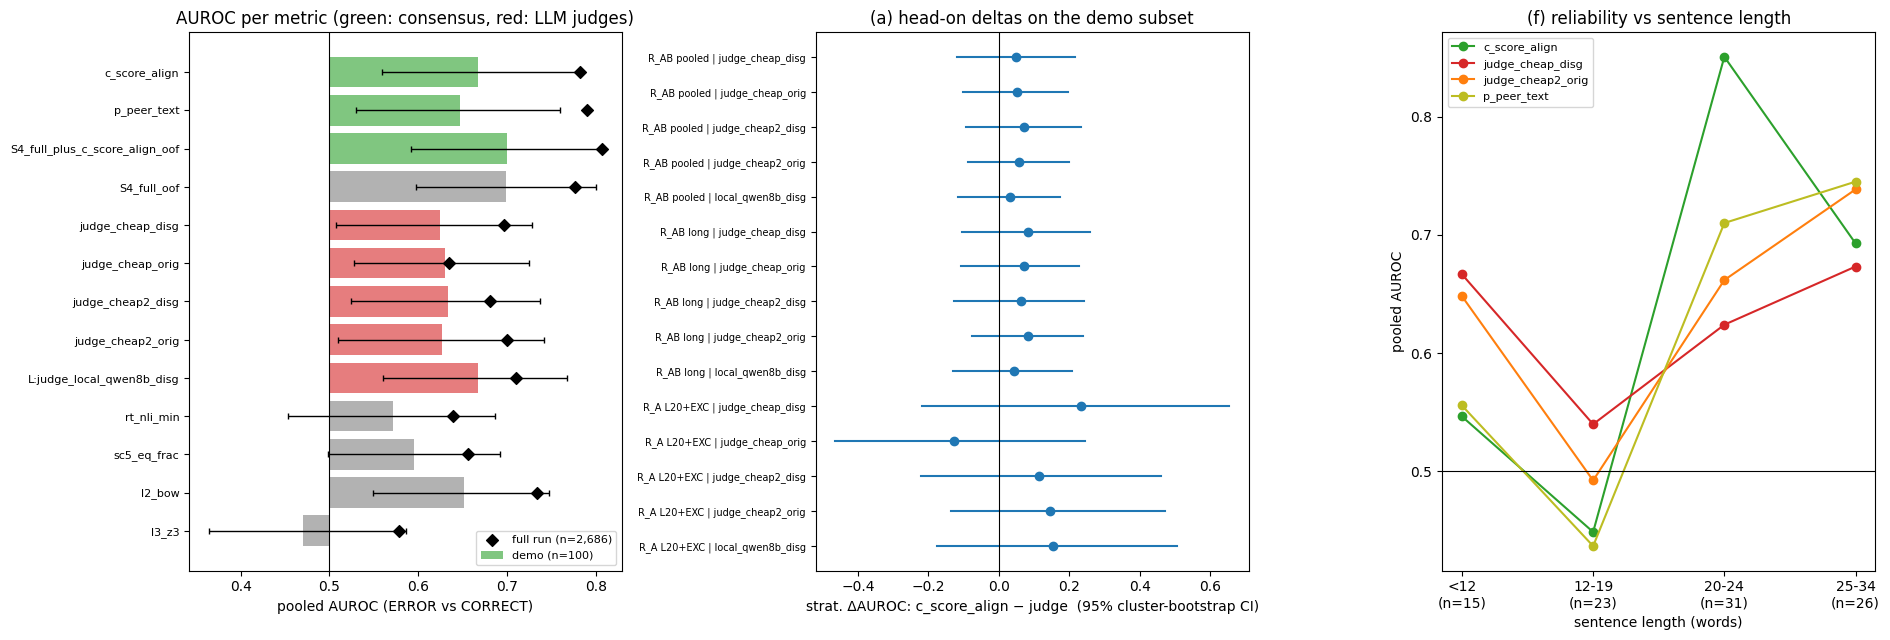

In [18]:
def lab(x):  # demo labels: with n=100 a failed CI test means "not shown at this n", not a disconfirmation
    return "holds on demo" if x is True else ("not shown at n=100" if x is False else "UNTESTABLE")
FV = META["full_run_verdict"]["criteria"]
ca_ = A["criterion_a"]["judge_cheap_disg"]
summary = pd.DataFrame([
    {"criterion": "(a) c_score_align > flash-lite disg (strat)", "demo": lab(ca_["holds"]),
     "demo numbers": f"R_AB {ca_['R_AB_strat']['delta']:+.3f} {np.round(ca_['R_AB_strat']['ci'], 3).tolist()}; long {ca_['long_strat']['delta']:+.3f}; R_A L20+EXC {ca_['R_A_L20EXC']['delta']:+.3f}",
     "full run": FV["a"]["status"], "full numbers": f"R_AB {FV['a']['R_AB_strat']['delta']:+.3f} {np.round(FV['a']['R_AB_strat']['ci'], 3).tolist()}"},
    {"criterion": "(b) nested [S4_full + c] - S4_full (strat)", "demo": lab(A["b_s4"]["criterion_b"]["holds"]),
     "demo numbers": f"{A['b_s4']['criterion_b']['strat']['delta']:+.3f} {np.round(A['b_s4']['criterion_b']['strat']['ci'], 3).tolist()}",
     "full run": FV["b"]["status"], "full numbers": f"{FV['b']['strat']['delta']:+.3f} {np.round(FV['b']['strat']['ci'], 3).tolist()}"},
    {"criterion": "(d) frontier ratio / nested gain", "demo": lab(A["d_frontier"]["criterion_d"].get("holds")),
     "demo numbers": f"ratio {A['d_frontier']['criterion_d'].get('ratio', float('nan')):.3f}; nested {A['d_frontier'].get('nested_frame', {}).get('delta', float('nan')):+.3f}",
     "full run": FV["d"]["status"], "full numbers": f"ratio {FV['d']['ratio']:.3f}; nested {META['full_run_frontier']['nested_frame']['delta']:+.3f}"},
])
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
# 1) AUROC per metric (demo, with CI) vs full run
show = ["c_score_align", "p_peer_text", "S4_full_plus_c_score_align_oof", "S4_full_oof", "judge_cheap_disg", "judge_cheap_orig",
        "judge_cheap2_disg", "judge_cheap2_orig", LOCAL_BAR, "rt_nli_min", "sc5_eq_frac", "l2_bow", "l3_z3"]
show = [m for m in show if m in A["metrics_R_AB"] and not A["metrics_R_AB"][m].get("untestable")]
ypos = np.arange(len(show))[::-1]
au = np.array([A["metrics_R_AB"][m]["auroc"] for m in show])
lo = np.array([A["metrics_R_AB"][m]["ci"][0] for m in show]); hi = np.array([A["metrics_R_AB"][m]["ci"][1] for m in show])
col = ["tab:green" if (m in CHALLENGERS or "plus_c" in m) else ("tab:red" if "judge" in m else "tab:gray") for m in show]
ax = axes[0]
ax.barh(ypos, au - 0.5, left=0.5, color=col, alpha=0.6, label="demo (n=%d)" % len(P))
ax.errorbar(au, ypos, xerr=[au - lo, hi - au], fmt="none", ecolor="k", capsize=2, lw=1)
ax.scatter([FULL.get(m, {}).get("pooled", np.nan) for m in show], ypos, marker="D", color="k", zorder=3, label="full run (n=2,686)")
ax.set_yticks(ypos); ax.set_yticklabels(show, fontsize=8); ax.axvline(0.5, color="k", lw=0.8)
ax.set_xlabel("pooled AUROC (ERROR vs CORRECT)"); ax.set_title("AUROC per metric (green: consensus, red: LLM judges)")
ax.legend(fontsize=8, loc="lower right")
# 2) forest plot of stratified deltas c_score_align - bar
ax = axes[1]
rowsF = []
for cname in ("R_AB pooled", "R_AB long (L25+L20+EXC)", "R_A L20+EXC"):
    for bb in bar_list:
        d = A["a_head_on"][cname]["deltas"].get(f"c_score_align - {bb} [strat]", {})
        if d and not d.get("untestable"):
            rowsF.append((f"{cname.split(' (')[0]} | {bb.replace('L:judge_local_', 'local_')}", d["delta"], d["ci"]))
yy = np.arange(len(rowsF))[::-1]
for yv, (lbl, dlt, ci) in zip(yy, rowsF):
    ax.plot(ci, [yv, yv], color="tab:blue"); ax.plot(dlt, yv, "o", color="tab:blue")
ax.axvline(0, color="k", lw=0.8); ax.set_yticks(yy); ax.set_yticklabels([r[0] for r in rowsF], fontsize=7)
ax.set_xlabel("strat. ΔAUROC: c_score_align − judge  (95% cluster-bootstrap CI)"); ax.set_title("(a) head-on deltas on the demo subset")
# 3) AUROC by sentence length
ax = axes[2]
res = A["f_complexity"]["words"]
labs_ = [l for l, r in res.items() if r.get("delta_c_minus_cheapdisg") and not r["delta_c_minus_cheapdisg"].get("untestable")]
for m, c_ in (("c_score_align", "tab:green"), ("judge_cheap_disg", "tab:red"), ("judge_cheap2_orig", "tab:orange"), ("p_peer_text", "tab:olive")):
    ax.plot(labs_, [res[l]["metrics"][m].get("auroc", np.nan) for l in labs_], "o-", color=c_, label=m)
ax.axhline(0.5, color="k", lw=0.8)
ax.set_xticks(range(len(labs_))); ax.set_xticklabels([f"{l}\n(n={res[l]['n']})" for l in labs_])
ax.set_xlabel("sentence length (words)"); ax.set_ylabel("pooled AUROC"); ax.set_title("(f) reliability vs sentence length")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()